In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Breast Cancer Dataset — Exploratory Data Analysis

## 1. Load & Dataset Overview

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df["target_name"] = df["target"].map({0: "malignant", 1: "benign"})

print("Shape:", df.shape)
print("\nTarget classes:", data.target_names.tolist())
print("\nFeature names:")
for i, name in enumerate(data.feature_names):
    print(f"  {i+1:2d}. {name}")

Shape: (569, 32)

Target classes: ['malignant', 'benign']

Feature names:
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error
  19. symmetry error
  20. fractal dimension error
  21. worst radius
  22. worst texture
  23. worst perimeter
  24. worst area
  25. worst smoothness
  26. worst compactness
  27. worst concavity
  28. worst concave points
  29. worst symmetry
  30. worst fractal dimension


In [11]:
print("=== General Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "total missing values")

print("\n=== Summary Statistics ===")
df.describe().T.round(2)

=== General Info ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


In [12]:
df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0,malignant
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0,malignant
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0,malignant
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0,malignant
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0,malignant


## 2. Class Distribution

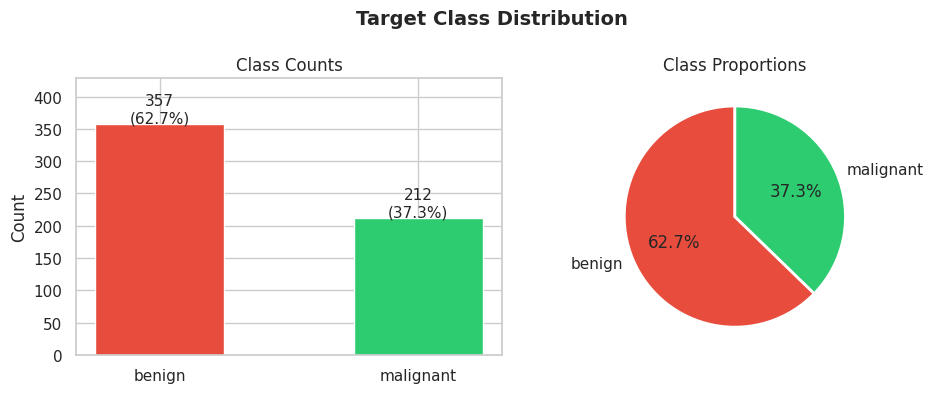

In [ ]:
counts = df["target_name"].value_counts()
pcts = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ["#e74c3c", "#2ecc71"]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.5)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 3, f"{v}\n({p:.1f}%)", ha="center", fontsize=11)
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportions")

plt.suptitle("Target Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Per-Class Feature Statistics

In [5]:
features = data.feature_names.tolist()

stats = df.groupby("target_name")[features].mean().T
stats.columns.name = None
stats["ratio_benign_malignant"] = (stats["benign"] / stats["malignant"]).round(2)
stats = stats.round(4)

print("Mean feature values by class (sorted by ratio):")
stats.sort_values("ratio_benign_malignant")

Mean feature values by class (sorted by ratio):


,benign,malignant,ratio_benign_malignant
mean concavity,0.0461,0.1608,0.29
mean concave points,0.0257,0.0880,0.29
area error,21.1351,72.6724,0.29
worst concavity,0.1662,0.4506,0.37
worst area,558.8994,1422.2863,0.39
worst concave points,0.0744,0.1822,0.41
perimeter error,2.0003,4.3239,0.46
mean area,462.7902,978.3764,0.47
radius error,0.2841,0.6091,0.47
worst compactness,0.1827,0.3748,0.49


## 4. Feature Distributions by Class

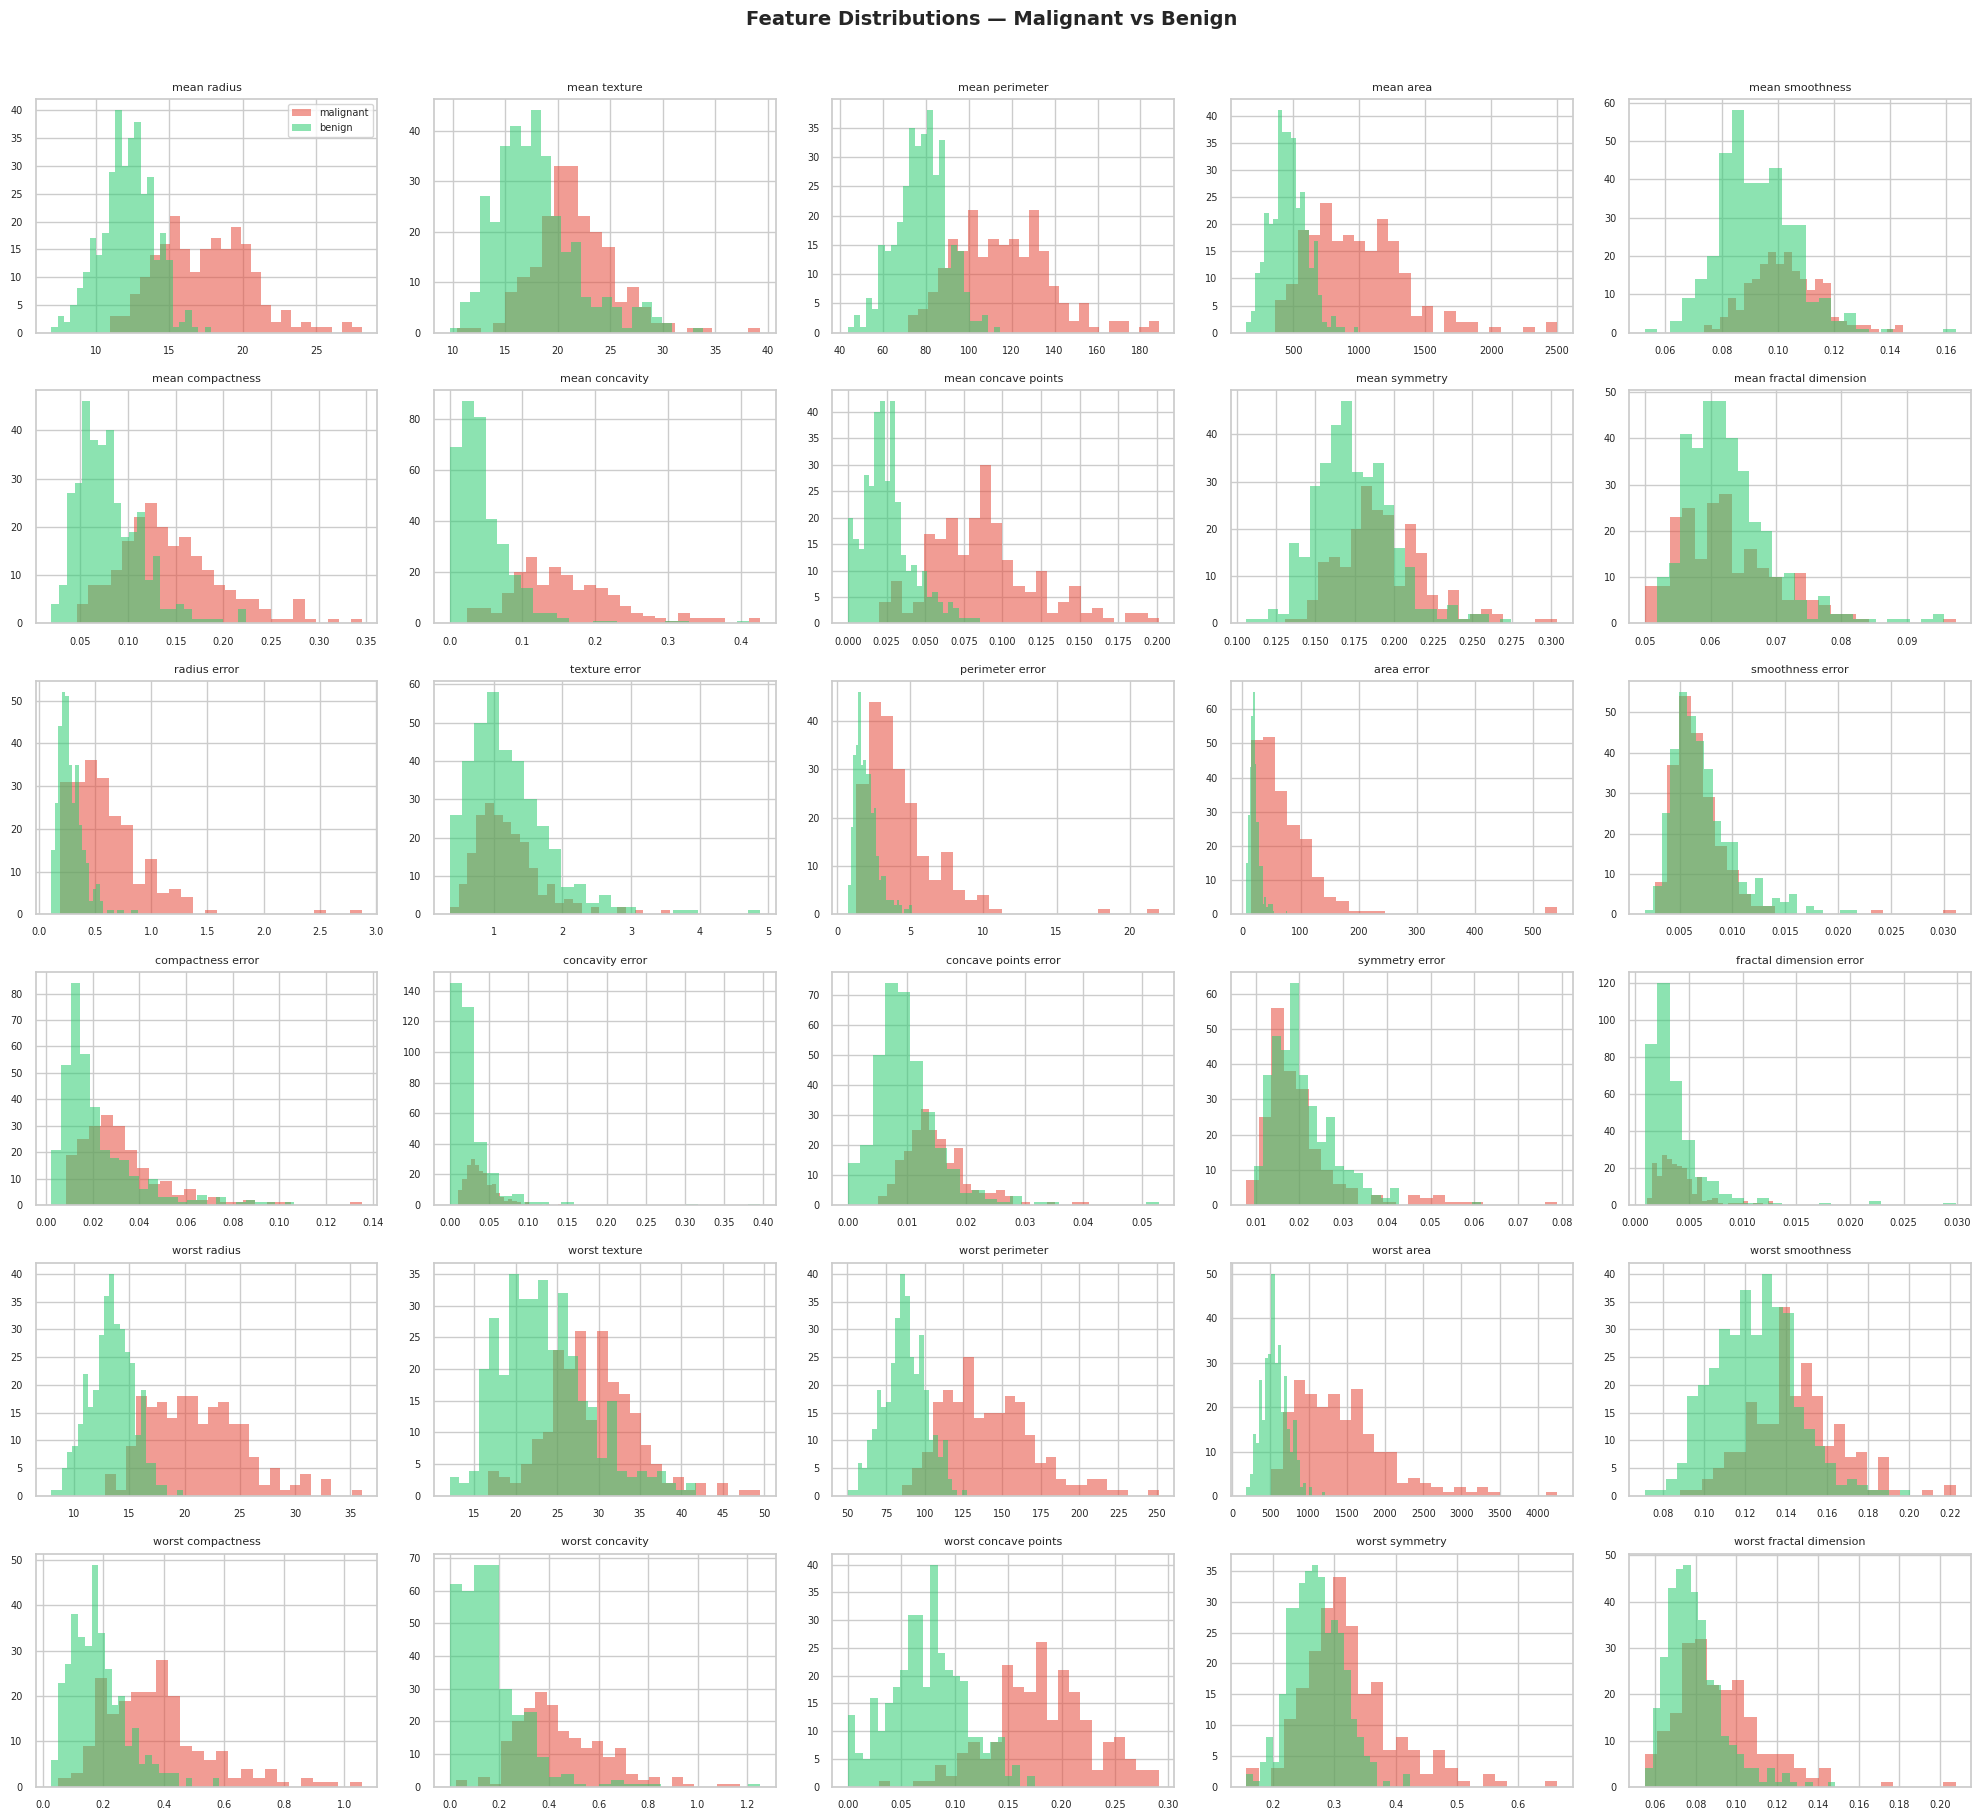

In [6]:
palette = {"malignant": "#e74c3c", "benign": "#2ecc71"}

n_cols = 5
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, color in palette.items():
        subset = df[df["target_name"] == label][feat]
        axes[i].hist(subset, bins=25, alpha=0.55, color=color, label=label, edgecolor="none")
    axes[i].set_title(feat, fontsize=8)
    axes[i].tick_params(labelsize=7)
    if i == 0:
        axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions — Malignant vs Benign", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Boxplots per Class

/tmp/ipykernel_152609/17636436.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


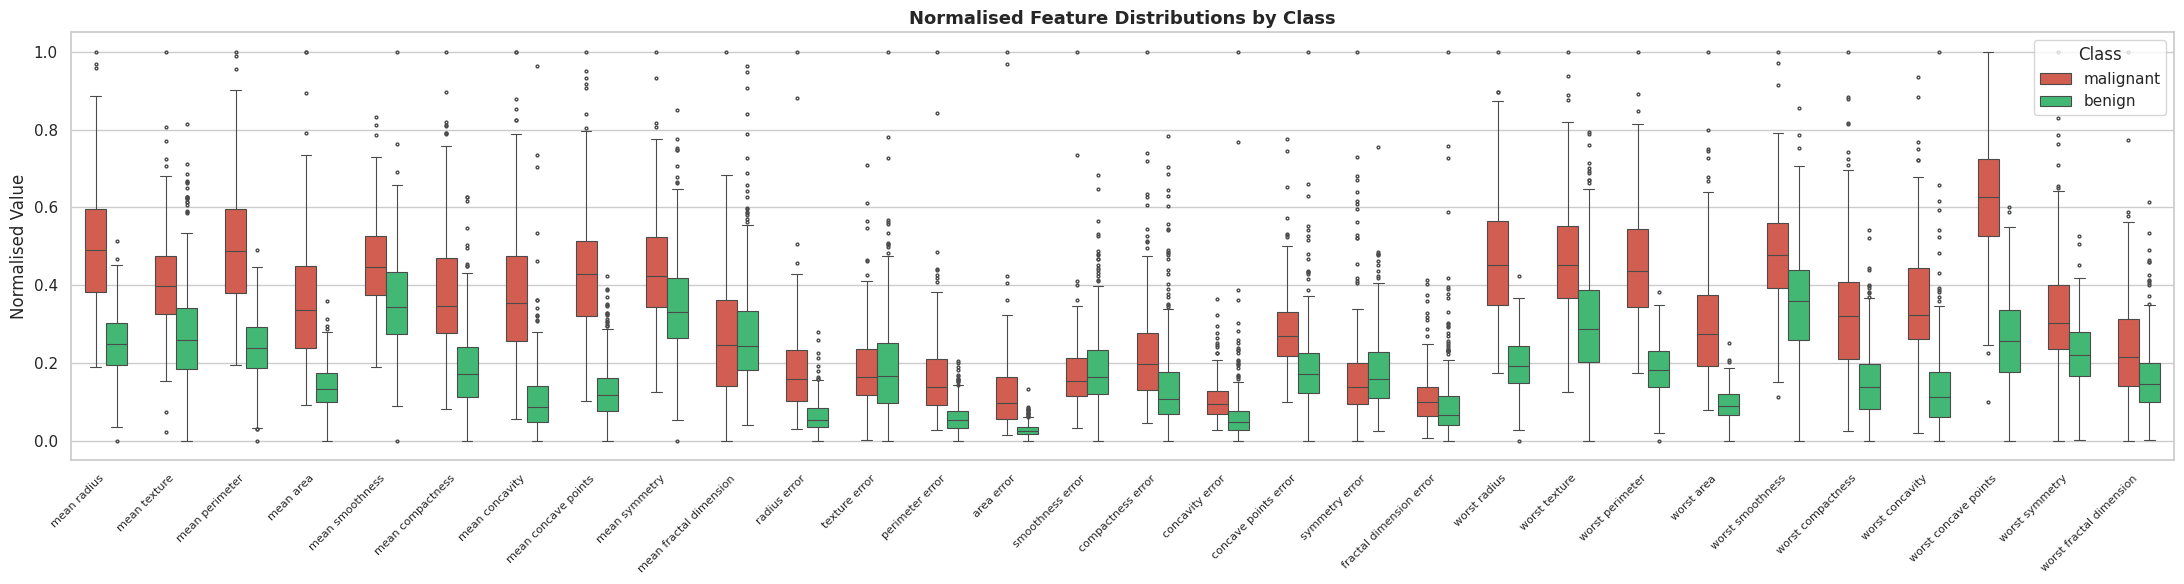

In [7]:
# Normalise features to [0,1] so all fit on the same axis
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)
df_norm["target_name"] = df["target_name"].values

df_melt = df_norm.melt(id_vars="target_name", var_name="feature", value_name="value")

fig, ax = plt.subplots(figsize=(22, 6))
sns.boxplot(data=df_melt, x="feature", y="value", hue="target_name",
            palette=palette, width=0.6, linewidth=0.8, fliersize=2, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_title("Normalised Feature Distributions by Class", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Normalised Value")
ax.legend(title="Class")
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

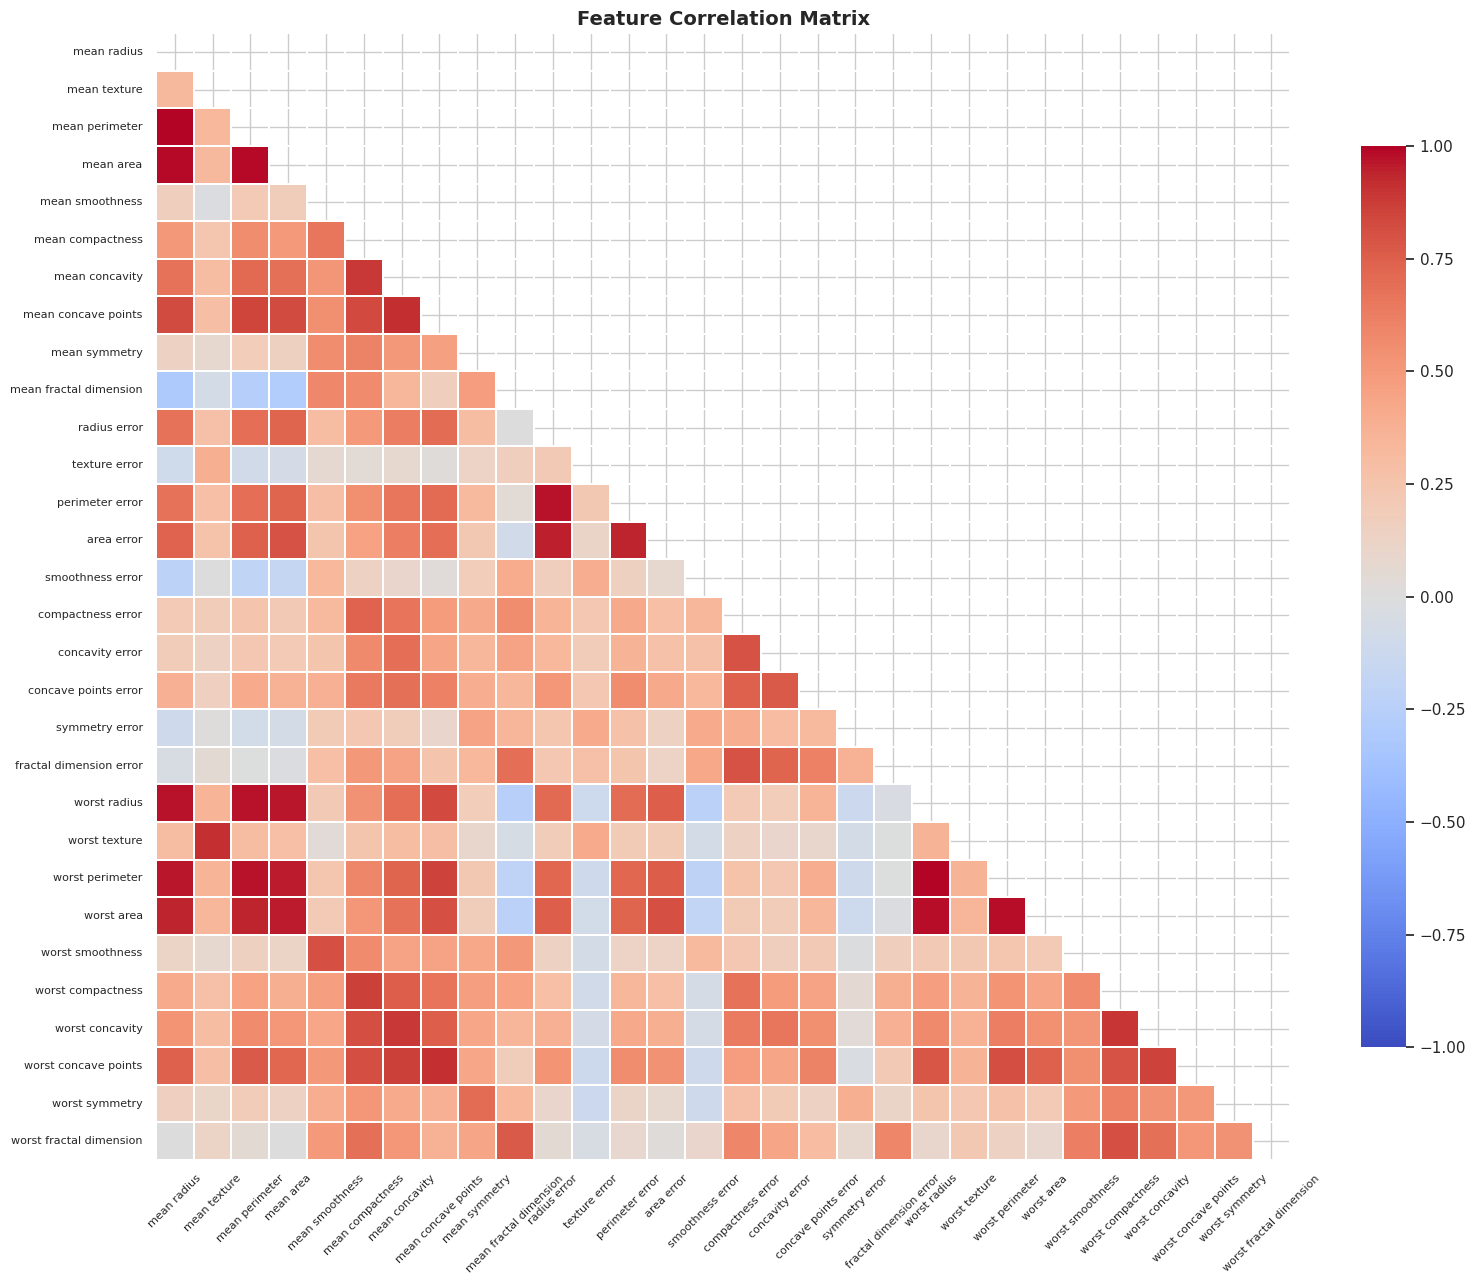

Top 10 most correlated feature pairs:


,feat_a,feat_b,correlation
60,mean perimeter,mean radius,0.997855
680,worst perimeter,worst radius,0.993708
90,mean area,mean radius,0.987357
92,mean area,mean perimeter,0.986507
710,worst area,worst radius,0.984015
712,worst area,worst perimeter,0.977578
370,perimeter error,radius error,0.972794
662,worst perimeter,mean perimeter,0.970387
600,worst radius,mean radius,0.969539
602,worst radius,mean perimeter,0.969476


In [8]:
corr = df[features].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, mask=mask, annot=False, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.3, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

# Top 10 most correlated pairs (excluding self)
corr_pairs = (corr.where(~mask)
              .stack()
              .reset_index()
              .rename(columns={"level_0": "feat_a", "level_1": "feat_b", 0: "correlation"}))
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
print("Top 10 most correlated feature pairs:")
corr_pairs.sort_values("abs_corr", ascending=False).head(10)[["feat_a", "feat_b", "correlation"]]

## 7. Pairplot — Top Discriminative Features

Top 6 features most correlated with target:
  worst concave points: 0.794
  worst perimeter: 0.783
  mean concave points: 0.777
  worst radius: 0.776
  mean perimeter: 0.743
  worst area: 0.734


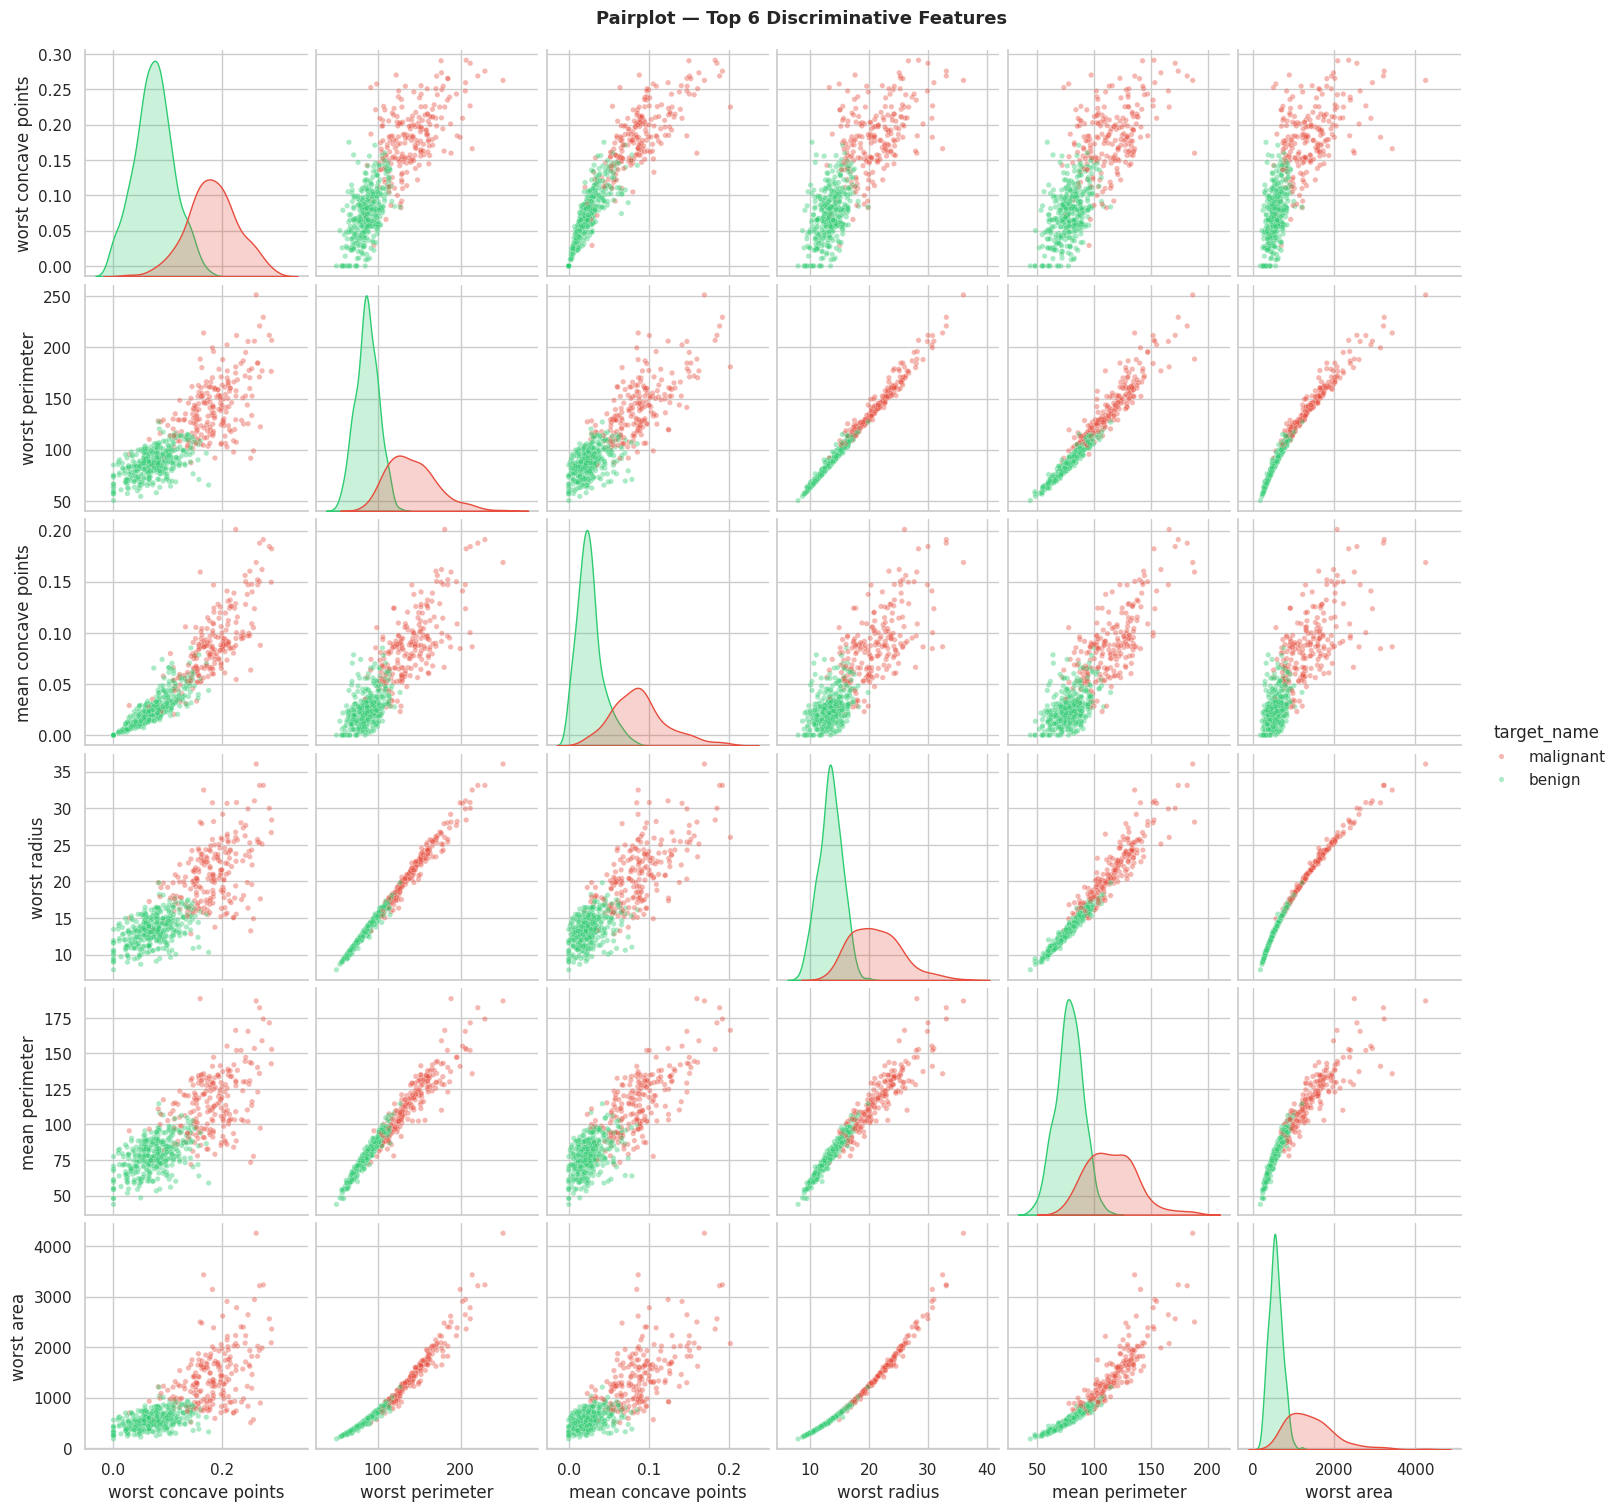

In [9]:
# Select top 6 features most correlated with the target (point-biserial via plain corr)
target_corr = df[features + ["target"]].corr()["target"].drop("target").abs()
top6 = target_corr.nlargest(6).index.tolist()

print("Top 6 features most correlated with target:")
for f in top6:
    print(f"  {f}: {target_corr[f]:.3f}")

pair_df = df[top6 + ["target_name"]]
g = sns.pairplot(pair_df, hue="target_name", palette=palette,
                 plot_kws={"alpha": 0.4, "s": 15},
                 diag_kind="kde")
g.figure.suptitle("Pairplot — Top 6 Discriminative Features", y=1.01, fontsize=13, fontweight="bold")
plt.show()

## 8. Feature Importance via Variance & Target Correlation

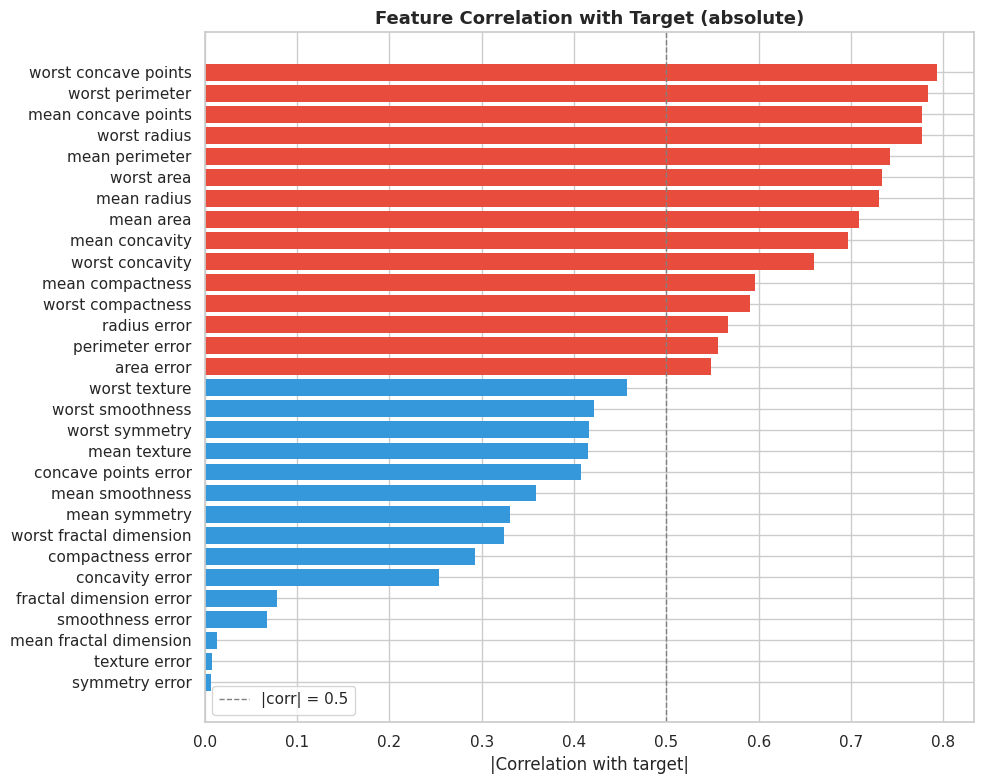

In [10]:
target_corr_sorted = target_corr.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ["#e74c3c" if v >= 0.5 else "#3498db" for v in target_corr_sorted.values]
bars = ax.barh(target_corr_sorted.index, target_corr_sorted.values, color=colors_bar, edgecolor="none")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, label="|corr| = 0.5")
ax.set_xlabel("|Correlation with target|")
ax.set_title("Feature Correlation with Target (absolute)", fontsize=13, fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()